In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [35]:
N=1000 # population size
generations = 100 # number of generations
r=0.0001 # recombination rate # check for different values of r, started with r=0.1

# Initial haplotype frequencies: [AB, Ab, aB , ab]
hap_freqs = np.array([0.25, 0.25, 0.25, 0.25])
hap_history = []


In [25]:
def compute_LD(freqs):
    f_AB, f_Ab, f_aB, f_Ab = freqs
    p_A = f_AB + f_Ab
    p_B = f_AB+f_aB
    D=f_AB - (p_A*p_B)
    return D
    

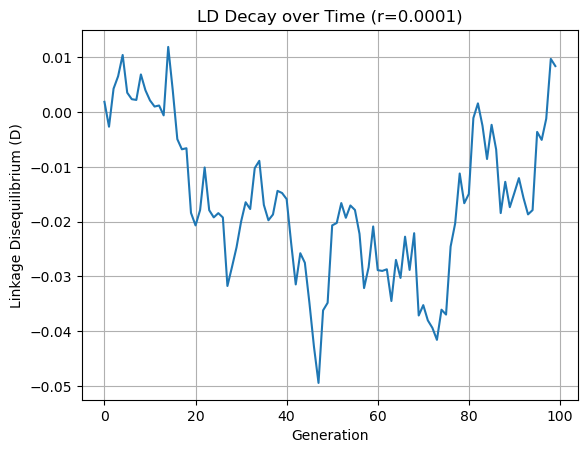

In [36]:
LD_over_time = []
for gen in range(generations):
    np.append(hap_history,hap_freqs.copy())
    #computng allele frequencies
    f_AB, f_Ab, f_aB, f_ab = hap_freqs
    p_A = f_AB + f_Ab
    p_B = f_AB + f_aB

    #Recombination step (breaks up and re-forms haplotypes)

    f_AB_new = (1-r)*f_AB + r*p_A*p_B
    f_Ab_new = (1-r)*f_Ab + r*p_A*(1-p_B)
    f_aB_new = (1-r)*f_aB + r*(1-p_A)*p_B
    f_ab_new = (1-r)*f_ab + r*(1-p_A)*(1-p_B)

    hap_freqs=np.array([f_AB_new, f_Ab_new, f_aB_new, f_ab_new])
    
    #Sampling step (genetic drift)
    hap_counts = np.random.multinomial(N, hap_freqs)
    hap_freqs = hap_counts/N

    #track LD
    D= compute_LD(hap_freqs)
    LD_over_time.append(D)

    hap_history = np.array(hap_history)

    #plot LD decay over time
plt.plot(LD_over_time)
plt.xlabel("Generation")
plt.ylabel("Linkage Disequilibrium (D)")
plt.title(f"LD Decay over Time (r={r})")
plt.grid(True)
plt.show()
    

In [23]:
hap_freqs.copy()
np.append(hap_history,hap_freqs.copy())

array([0.25 , 0.25 , 0.25 , 0.25 , 0.248, 0.26 , 0.243, 0.249])

# haplotype fixation probabilities

In [42]:
num_replicates =500
N=1000
fixation_counts = np.zeros(4)

for _ in range(num_replicates):
    freqs = np.array([0.25, 0.25, 0.25, 0.25])
    for gen in range(1200):
        counts = np.random.multinomial(N, freqs)
        freqs= counts/N

        if np.max(freqs) > 0.999:
            fixation_counts[np.argmax(freqs)] +=1
            break

fixation_probs =  fixation_counts /num_replicates
print("Fixation probabilities for [AB, Ab, aB, ab]:", fixation_probs)

Fixation probabilities for [AB, Ab, aB, ab]: [0.118 0.088 0.078 0.088]


# Fixation With Selection

In [45]:
#how selection increases fixation probability for AB

fitness = np.array([1.1, 1.0, 1.0, 1.0])  # AB is favored

for _ in range(num_replicates):
    freqs = np.array([0.25, 0.25, 0.25, 0.25])
    for gen in range(1200):
        weighted_freqs = freqs * fitness
        weighted_freqs /= weighted_freqs.sum()

        counts = np.random.multinomial(N, weighted_freqs)
        freqs = counts / N

        if np.max(freqs) > 0.999:
            fixation_counts[np.argmax(freqs)] += 1
            break
fixation_probs =  fixation_counts /num_replicates
print("Fixation probabilities for [AB, Ab, aB, ab]:", fixation_probs)

Fixation probabilities for [AB, Ab, aB, ab]: [3.118 0.088 0.078 0.088]


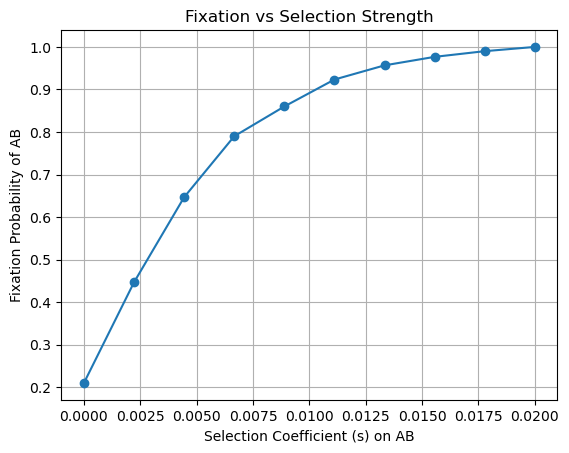

In [50]:
#how increasing selection strength s on one haplotype (e.g., AB) increases its chance of fixation.
N = 500
num_replicates = 300
generations = 1500
s_values = np.linspace(0, 0.02, 10)
fixation_probs = []

for s in s_values:
    fixation_counts = 0  # Only track fixation of AB
    for _ in range(num_replicates):
        freqs = np.array([0.25, 0.25, 0.25, 0.25])
        fitness = np.array([1 + s, 1.0, 1.0, 1.0])
        for _ in range(generations):
            weighted = freqs * fitness
            weighted /= weighted.sum()
            counts = np.random.multinomial(N, weighted)
            freqs = counts / N
            if freqs[0] > 0.999:  #here you can change for why genotype you wan to see 0:AB, 1:Ab, 2:aB ,3: ab
                fixation_counts += 1
                break
    fixation_probs.append(fixation_counts / num_replicates)

# Plotting
plt.plot(s_values, fixation_probs, marker='o')
plt.xlabel("Selection Coefficient (s) on AB")
plt.ylabel("Fixation Probability of AB")
plt.title("Fixation vs Selection Strength")
plt.grid(True)
plt.show()

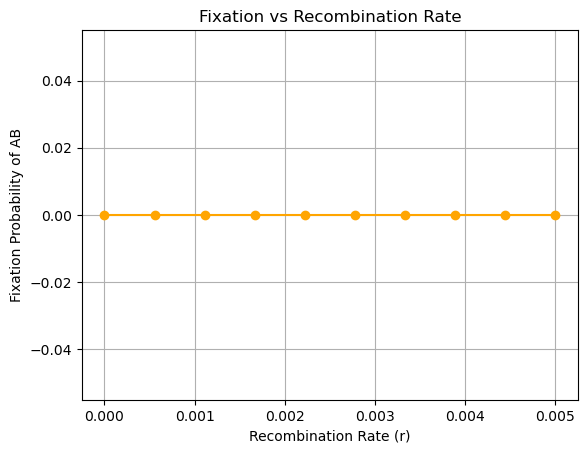

In [54]:
def recombine(freqs, r):
    D = freqs[0]*freqs[3] - freqs[1]*freqs[2]
    freqs[0] -= r * D
    freqs[1] += r * D
    freqs[2] += r * D
    freqs[3] -= r * D
    return freqs

r_values = np.linspace(0, 0.005, 10)
fixation_probs_r = []

for r in r_values:
    fix_count = 0
    for _ in range(num_replicates):
        freqs = np.array([1/N, 0.5 - 0.5/N, 0.5, 0.0])
        fitness = np.array([1.1, 1.0, 1.0, 1.0])
        for _ in range(generations):
            freqs = recombine(freqs, r)
            weighted = freqs * fitness
            weighted /= weighted.sum()
            counts = np.random.multinomial(N, weighted)
            freqs = counts / N
            if freqs[3] > 0.999:
                fix_count += 1
                break
    fixation_probs_r.append(fix_count / num_replicates)

# Plotting
plt.plot(r_values, fixation_probs_r, marker='o', color='orange')
plt.xlabel("Recombination Rate (r)")
plt.ylabel("Fixation Probability of AB")
plt.title("Fixation vs Recombination Rate")
plt.grid(True)
plt.show()
